In [ ]:
"""
Hybrid Transformer + Neural Spline Flow with Modern Architecture Choices - OPTIMIZED VERSION
- Vectorized operations for significant speedup
- RMSNorm for efficiency and stability
- Pre-norm architecture for better gradient flow
- Bias-free projections and attention layers
- GroupNorm in flow layers for batch-size independence
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Optional, Tuple, List, Dict
import math
from torch.cuda.amp import GradScaler, autocast
from vit_wpos_embed import *
from torch.distributions import HalfNormal

class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization.
    More efficient than LayerNorm, used in LLaMA and Gemma.
    """
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # RMS normalization
        norm = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)
        return x / norm * self.weight


class Attention(nn.Module):
    """
    Custom Multi-Head Attention module with KV Caching support.
    """
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1, bias: bool = False):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by n_heads ({n_heads})")

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.dropout = dropout

        self.q_proj = nn.Linear(d_model, d_model, bias=bias)
        self.k_proj = nn.Linear(d_model, d_model, bias=bias)
        self.v_proj = nn.Linear(d_model, d_model, bias=bias)
        self.out_proj = nn.Linear(d_model, d_model, bias=bias)


    def forward(
        self,
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        attn_mask: Optional[torch.Tensor] = None,
        key_padding_mask: Optional[torch.Tensor] = None,
        past_key_value: Optional[Tuple[torch.Tensor, torch.Tensor]] = None
    ) -> Tuple[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass for attention with optional KV cache.

        Args:
            query: Query tensor [batch_size, query_len, d_model]
            key: Key tensor [batch_size, kv_len, d_model]
            value: Value tensor [batch_size, kv_len, d_model]
            attn_mask: Additional attention mask [batch_size, n_heads, query_len, kv_len] or broadcastable
            key_padding_mask: Padding mask for keys [batch_size, kv_len] where True = padded
            past_key_value: Tuple of (past_key, past_value)

        Returns:
            Tuple of (attention_output, present_key_value)
        """
        batch_size, query_len, _ = query.shape
        _, kv_len, _ = key.shape

        # 1. Project Q, K, V
        q = self.q_proj(query)
        k = self.k_proj(key)
        v = self.v_proj(value)

        # 2. Reshape for multi-head attention
        q = q.view(batch_size, query_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, kv_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, kv_len, self.n_heads, self.head_dim).transpose(1, 2)

        # 3. Handle KV Cache
        if past_key_value is not None:
            past_k, past_v = past_key_value
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)

        present_key_value = (k, v)

        # Update kv_len to include cached length
        cached_kv_len = k.shape[2]
        
        # 4. Create attention mask
        # Corrected logic to handle causal and padding masks simultaneously
        
        # Determine if this pass should be causal (i.e., for self-attention during training)
        is_causal_pass = query_len > 1 and past_key_value is None

        final_mask = None
        use_is_causal_flag = False
        if key_padding_mask is not None:
            key_padding_mask = key_padding_mask[:,:,0]
        if is_causal_pass:
            if key_padding_mask is not None:
                # Case 1: Causal + Padding. Must create a combined mask manually.
                causal_mask = torch.tril(torch.ones(query_len, cached_kv_len, dtype=torch.bool, device=q.device))
                padding_mask = (~key_padding_mask).view(batch_size, 1, 1, cached_kv_len)
                final_mask = causal_mask & padding_mask
            else:
                # Case 2: Causal only. Can use the efficient built-in flag.
                use_is_causal_flag = True
        elif key_padding_mask is not None:
            # Case 3: Padding only.
            final_mask = (~key_padding_mask).view(batch_size, 1, 1, cached_kv_len)

        # Also account for an explicit attn_mask if provided
        if attn_mask is not None:
            if final_mask is not None:
                 final_mask = final_mask & attn_mask
            else:
                 final_mask = attn_mask

        # 5. Scaled Dot-Product Attention
        attn_output = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=final_mask,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=use_is_causal_flag # This is now correctly set
        )

        # 6. Reshape and Output Projection
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, query_len, self.d_model)
        output = self.out_proj(attn_output)

        return output, present_key_value


def searchsorted(bin_locations, inputs, eps=1e-6):
    """
    Searches for which bin each input falls into.
    """
    bin_locations = bin_locations[..., :-1] + eps
    return torch.sum(inputs[..., None] >= bin_locations, dim=-1) - 1

def rational_quadratic_spline(
    inputs,
    widths,
    heights,
    derivatives,
    inverse=False,
    left=0.0,
    right=1.0,
    bottom=0.0,
    top=1.0,
    min_bin_width=1e-3,
    min_bin_height=1e-3,
    min_derivative=1e-3
):
    """
    Rational-quadratic spline transformation.

    Args:
        inputs: Input tensor
        widths: Bin widths
        heights: Bin heights
        derivatives: Derivatives at knots
        inverse: If True, compute inverse transform
        left, right, bottom, top: Bounds for transformation
        min_bin_width, min_bin_height, min_derivative: Minimum values for numerical stability

    Returns:
        outputs: Transformed values
        log_abs_det: Log absolute determinant of Jacobian
    """
    num_bins = widths.shape[-1]

    if min_bin_width * num_bins > 1.0:
        raise ValueError('min_bin_width * num_bins must be less than 1')
    if min_bin_height * num_bins > 1.0:
        raise ValueError('min_bin_height * num_bins must be less than 1')

    # Normalize widths and heights
    widths = F.softmax(widths, dim=-1)
    widths = min_bin_width + (1 - min_bin_width * num_bins) * widths
    cumwidths = torch.cumsum(widths, dim=-1)
    cumwidths = F.pad(cumwidths, (1, 0), mode='constant', value=0.0)
    cumwidths = (right - left) * cumwidths + left
    cumwidths[..., 0] = left
    cumwidths[..., -1] = right
    widths = cumwidths[..., 1:] - cumwidths[..., :-1]

    heights = F.softmax(heights, dim=-1)
    heights = min_bin_height + (1 - min_bin_height * num_bins) * heights
    cumheights = torch.cumsum(heights, dim=-1)
    cumheights = F.pad(cumheights, (1, 0), mode='constant', value=0.0)
    cumheights = (top - bottom) * cumheights + bottom
    cumheights[..., 0] = bottom
    cumheights[..., -1] = top
    heights = cumheights[..., 1:] - cumheights[..., :-1]

    # Corrected: Ensure positive derivatives for interior knots, then pad with 1s for the boundaries
    derivatives = F.softplus(derivatives) + min_derivative
    derivatives = F.pad(derivatives, (1, 1), mode='constant', value=1.0)

    if inverse:
        # Inverse transform
        bin_idx = searchsorted(cumheights, inputs)
    else:
        # Forward transform
        bin_idx = searchsorted(cumwidths, inputs)

    # Clamp bin_idx to be within the valid range [0, num_bins-1].
    # This handles inputs that fall outside the defined tail_bounds.
    bin_idx = bin_idx.clamp(min=0, max=num_bins - 1)

    # Gather parameters for the relevant bins
    input_cumwidths = cumwidths.gather(-1, bin_idx.unsqueeze(-1)).squeeze(-1)
    input_bin_widths = widths.gather(-1, bin_idx.unsqueeze(-1)).squeeze(-1)

    input_cumheights = cumheights.gather(-1, bin_idx.unsqueeze(-1)).squeeze(-1)
    input_bin_heights = heights.gather(-1, bin_idx.unsqueeze(-1)).squeeze(-1)

    input_derivatives = derivatives.gather(-1, bin_idx.unsqueeze(-1)).squeeze(-1)
    input_derivatives_plus_one = derivatives.gather(-1, (bin_idx + 1).unsqueeze(-1)).squeeze(-1)

    if inverse:
        # Compute inverse
        a = (inputs - input_cumheights) * (
            input_derivatives + input_derivatives_plus_one - 2
        ) + input_bin_heights * input_derivatives
        b = input_bin_heights * input_derivatives - (inputs - input_cumheights) * (
            input_derivatives + input_derivatives_plus_one - 2
        )
        c = -input_derivatives * (inputs - input_cumheights)

        discriminant = b.pow(2) - 4 * a * c
        # assert (discriminant >= 0).all(), "Discriminant must be non-negative"
        discriminant = (discriminant + 1e-8).clamp(min=0)

        xi = (2 * c) / (-b - torch.sqrt(discriminant + 1e-6))
        outputs = xi * input_bin_widths + input_cumwidths

        # Compute derivative for log determinant
        derivative_numerator = input_derivatives.pow(2) * (
            input_derivatives_plus_one * xi.pow(2) + 2 * input_derivatives * xi * (1 - xi) +
            input_derivatives_plus_one * (1 - xi).pow(2)
        )
        derivative_denominator = (
            input_derivatives + (input_derivatives_plus_one - input_derivatives) * xi
        ).pow(2)
        log_abs_det = -torch.log(derivative_numerator / derivative_denominator + 1e-8)

    else:
        # Compute forward transform
        xi = (inputs - input_cumwidths) / input_bin_widths

        numerator = input_bin_heights * (
            input_derivatives * xi.pow(2) + input_derivatives_plus_one * (1 - xi).pow(2)
        )
        denominator = input_derivatives + (
            input_derivatives_plus_one - input_derivatives
        ) * xi
        outputs = input_cumheights + numerator / denominator

        # Compute derivative for log determinant
        derivative_numerator = input_derivatives.pow(2) * (
            input_derivatives_plus_one * xi.pow(2) + 2 * input_derivatives * xi * (1 - xi) +
            input_derivatives_plus_one * (1 - xi).pow(2)
        )
        derivative_denominator = (
            input_derivatives + (input_derivatives_plus_one - input_derivatives) * xi
        ).pow(2)
        log_abs_det = torch.log(derivative_numerator / derivative_denominator + 1e-8)

    return outputs, log_abs_det

class NeuralSplineFlowLayer(nn.Module):
    """
    Neural spline flow layer with conditional transformations.
    Uses GroupNorm for batch-size independence.
    """

    def __init__(self, dim: int = 6, hidden_dim: int = 128, context_dim: int = 768,
                 n_bins: int = 8, tail_bound_min: float = -3.0, tail_bound_max: float = 3.0, n_groups: int = 8):
        super().__init__()
        self.dim = dim
        self.n_bins = n_bins
        self.tail_bound_min = tail_bound_min
        self.tail_bound_max = tail_bound_max


        # Network to compute spline parameters from context
        # Corrected: We need n_bins widths, n_bins heights, and n_bins-1 interior derivatives
        params_per_dim = 3 * n_bins - 1

        # Bias-free linear layers with GroupNorm
        self.context_net = nn.Sequential(
            nn.Linear(context_dim, hidden_dim, bias=False),
            nn.GroupNorm(n_groups, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim, bias=False),
            nn.GroupNorm(n_groups, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim * params_per_dim, bias=False)
        )

        # Initialize last layer with small weights
        nn.init.normal_(self.context_net[-1].weight, 0, 0.001)

    def forward(self, x: torch.Tensor, context: torch.Tensor, reverse: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward or reverse pass through neural spline flow layer.

        Args:
            x: Input tensor [batch_size, seq_len, 6] or [n_elements, 6]
            context: Context from transformer [batch_size, seq_len, context_dim] or [n_elements, context_dim]
            reverse: If True, perform inverse transformation

        Returns:
            Transformed tensor and log determinant of Jacobian
        """
        # Handle both batched and flattened inputs
        original_shape = x.shape
        if x.dim() == 3:
            batch_size, seq_len, dim = x.shape
            x = x.reshape(-1, dim)
            context = context.reshape(-1, context.shape[-1])
        else:
            batch_size = x.shape[0]
            dim = x.shape[1]

        # Compute spline parameters
        params = self.context_net(context)
        # Corrected: Reshape to the correct number of parameters
        params = params.reshape(-1, dim, 3 * self.n_bins - 1)

        # Split parameters
        widths = params[..., :self.n_bins]
        heights = params[..., self.n_bins:2*self.n_bins]
        derivatives = params[..., 2*self.n_bins:] # This will now correctly have n_bins-1 elements

        # Apply spline transformation to each dimension
        outputs = []
        log_dets = []

        for d in range(dim):
            out, log_det = rational_quadratic_spline(
                x[:, d],
                widths[:, d, :],
                heights[:, d, :],
                derivatives[:, d, :],
                inverse=reverse,
                left=self.tail_bound_min,
                right=self.tail_bound_max,
                bottom=self.tail_bound_min,
                top=self.tail_bound_max
            )
            outputs.append(out)
            log_dets.append(log_det)

        # Stack outputs
        output = torch.stack(outputs, dim=-1)
        log_det_total = torch.stack(log_dets, dim=-1).sum(dim=-1)

        # Reshape back to original shape
        if len(original_shape) == 3:
            output = output.reshape(original_shape)
            log_det_total = log_det_total.reshape(batch_size, -1)

        return output, log_det_total


class ConditionalNormalizingFlow(nn.Module):
    """
    Stack of neural spline flow layers for full expressivity.
    """

    def __init__(self, dim: int = 6, n_layers: int = 4, hidden_dim: int = 128,
                 context_dim: int = 768, n_bins: int = 8, tail_bound_min: float = -3.0,
                 tail_bound_max: float = 3.0, n_groups: int = 8):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers

        # Create neural spline flow layers with GroupNorm
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            self.layers.append(
                NeuralSplineFlowLayer(dim, hidden_dim, context_dim, n_bins, tail_bound_min, 
                tail_bound_max, n_groups)
            )

        # Learnable permutation parameters
        self.register_buffer('permute_indices', torch.arange(dim))
        
    def get_permutation(self, layer_idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Get permutation and inverse permutation for a given layer."""
        if layer_idx % 2 == 0:
            return self.permute_indices, torch.argsort(self.permute_indices)
        else:
            # Simple alternating pattern: reverse for odd layers
            perm = torch.arange(self.dim - 1, -1, -1, device=self.permute_indices.device)
            return perm, perm  # Reverse is its own inverse

    def forward(self, x: torch.Tensor, context: torch.Tensor, reverse: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Full forward or reverse pass through the flow.

        Args:
            x: Input tensor [batch_size, seq_len, 6] or [n_elements, 6]
            context: Context from transformer [batch_size, seq_len, context_dim] or [n_elements, context_dim]
            reverse: If True, perform inverse transformation

        Returns:
            Transformed tensor and log determinant of Jacobian
        """
        # Initialize log determinant
        if x.dim() == 3:
            log_det_total = torch.zeros(x.shape[0], x.shape[1], device=x.device)
        else:
            log_det_total = torch.zeros(x.shape[0], device=x.device)

        if not reverse:
            # Forward pass through flow
            for i, layer in enumerate(self.layers):
                # Get permutation for this layer
                perm, inv_perm = self.get_permutation(i)
                
                # Apply permutation
                x = x[..., perm]
                
                # Apply flow layer
                x, log_det = layer(x, context, reverse=False)
                log_det_total = log_det_total + log_det
                
                # Apply inverse permutation
                x = x[..., inv_perm]
        else:
            # Reverse pass through flow (for generation)
            for i in reversed(range(len(self.layers))):
                layer = self.layers[i]
                
                # Get permutation for this layer
                perm, inv_perm = self.get_permutation(i)
                
                # Apply permutation
                x = x[..., perm]
                
                # Apply flow layer
                x, log_det = layer(x, context, reverse=True)
                log_det_total = log_det_total + log_det
                
                # Apply inverse permutation
                x = x[..., inv_perm]

        return x, log_det_total


class ContinuousTransformerBlock(nn.Module):
    """
    Transformer block with pre-norm architecture and bias-free attention.
    Uses RMSNorm and follows modern LLM design patterns.
    """

    def __init__(self, d_model: int = 768, n_heads: int = 12, d_ff: int = 3072, dropout: float = 0.1):
        super().__init__()

        # Pre-norm for self-attention
        self.norm1 = RMSNorm(d_model)
        self.self_attention = Attention(d_model, n_heads, dropout=dropout, bias=False)

        # Pre-norm for cross-attention
        self.norm2 = RMSNorm(d_model)
        self.cross_attention = Attention(d_model, n_heads, dropout=dropout, bias=False)

        # Pre-norm for feed-forward
        self.norm3 = RMSNorm(d_model)

        # Bias-free feed-forward network with SwiGLU activation (used in LLaMA)
        self.w1 = nn.Linear(d_model, d_ff, bias=False)
        self.w2 = nn.Linear(d_model, d_ff, bias=False)
        self.w3 = nn.Linear(d_ff, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)


    def forward(
        self,
        x: torch.Tensor,
        field_embeddings: Optional[torch.Tensor] = None,
        self_padding_mask: Optional[torch.Tensor] = None,
        field_key_padding_mask: Optional[torch.Tensor] = None,
        past_key_value: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
        use_cache: bool = False
    ) -> Tuple[torch.Tensor, Optional[Tuple[torch.Tensor, torch.Tensor]]]:
        """
        Forward pass through transformer block with pre-norm and optional KV cache.
        """
        # --- Start of Correction ---
        # The cache is only for the self-attention layer.
        present_self_attn_cache = None

        # 1. Pre-norm self-attention with residual and KV cache
        normed = self.norm1(x)
        attn_out, present_self_attn_cache = self.self_attention(
            query=normed, key=normed, value=normed,
            key_padding_mask=self_padding_mask,
            past_key_value=past_key_value
        )
        x = x + attn_out

        # 2. Pre-norm cross-attention with residual (if field embeddings provided)
        if field_embeddings is not None:
            normed = self.norm2(x)
            
            # For cross-attention, K and V are static and come from field_embeddings.
            # NO KV-cache is used here.
            cross_attn_out, _ = self.cross_attention(
                query=normed, key=field_embeddings, value=field_embeddings,
                key_padding_mask=field_key_padding_mask,
                past_key_value=None # Explicitly disable caching for cross-attention
            )
            x = x + cross_attn_out

        # 3. Pre-norm feed-forward with SwiGLU and residual
        normed = self.norm3(x)
        ff_out = self.w3(F.silu(self.w1(normed)) * self.w2(normed))
        x = x + self.dropout(ff_out)

        # Return the cache for the self-attention layer ONLY.
        return x, present_self_attn_cache if use_cache else None


class HybridTransformerFlow(nn.Module):
    """
    Main model combining continuous transformer with neural spline flows.
    Modern architecture with RMSNorm, pre-norm, bias-free layers, and GroupNorm.

    Key features:
    - Pre-norm transformer blocks with RMSNorm
    - Bias-free attention and projections
    - GroupNorm in flow layers for batch independence
    - SwiGLU activation in feed-forward layers
    - Matrix input format with -100 padding
    - OPTIMIZED with vectorized operations
    """

    def __init__(
        self,
        config_dict
    ):
        super().__init__()
        # extract all the config dict keys as self attributes
        for key, value in config_dict.items():
            setattr(self, key, value)

        self.max_seq_len = self.max_blocks * self.input_dim  # Max sequence length in elements
        # Special learned embeddings for control tokens
        self.start_embedding = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        # Padding embedding as a fixed zero tensor (not learnable)
        self.register_buffer('pad_embedding', torch.zeros(1, self.d_model))

        # Bias-free linear projections
        self.input_projection = nn.Linear(self.input_dim, self.d_model, bias=False)
        self.output_projection = nn.Linear(self.d_model, self.input_dim, bias=False)


        # Learned positional encoding
        # self.pos_encoding = nn.Parameter(torch.randn(1, self.max_seq_len) * 0.02)
        self.pos_encoding = nn.Parameter(torch.randn(1, self.max_blocks) * 0.02)        

        # Transformer blocks with modern architecture
        self.transformer_blocks = nn.ModuleList([
            ContinuousTransformerBlock(self.d_model, self.n_heads, self.d_ff, self.dropout_val)
            for _ in range(self.n_layers)
        ])

        # Final RMSNorm before output heads
        self.final_norm = RMSNorm(self.d_model)

        # Neural spline flow with GroupNorm
        self.flow = ConditionalNormalizingFlow(
            self.input_dim, self.flow_layers, self.flow_hidden, self.d_model, self.n_bins, 
            self.tail_bound_min, self.tail_bound_max, self.n_groups
        )

        self.vit3D = Vision3DTransformer(
            in_channels=self.ninp_density,
            patch_size=self.patch_size,
            embed_dim=self.d_model,
            depth=self.n_layers_vit,
            num_heads=self.n_heads_vit,
            dropout=self.dropout_val,
            cross_attn_dim=self.d_model - self.nparams,
            layers_types=self.layers_types
        )

        # Binary decision head (bias-free)
        self.decision_head = nn.Linear(self.d_model, 2, bias=False)

        # Dropout
        self.dropout = nn.Dropout(self.dropout_val)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        """Initialize weights following modern practices."""
        # Initialize linear layers
        def init_linear(module):
            if isinstance(module, nn.Linear):
                # Use scaled initialization (GPT-2 style)
                std = 0.02
                nn.init.normal_(module.weight, mean=0.0, std=std)

        self.apply(init_linear)

        # Special initialization for output projections (smaller)
        nn.init.normal_(self.output_projection.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.n_layers))
        nn.init.normal_(self.decision_head.weight, mean=0.0, std=0.02 / math.sqrt(2 * self.n_layers))

    def create_padding_mask(self, seq_lengths: torch.Tensor, max_len: int, device: torch.device) -> torch.Tensor:
        """
        OPTIMIZED: Vectorized creation of padding mask.
        
        Args:
            seq_lengths: Tensor of sequence lengths [batch_size]
            max_len: Maximum sequence length
            device: Device to create mask on
            
        Returns:
            Padding mask [batch_size, max_len] where True indicates padded positions
        """
        batch_size = seq_lengths.shape[0]
        position_indices = torch.arange(max_len, device=device).unsqueeze(0).expand(batch_size, -1)
        mask = position_indices >= seq_lengths.unsqueeze(1)
        return mask

    def matrix_to_sequences(self, data_matrix: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        OPTIMIZED: Vectorized conversion from matrix format to sequences.
        
        Args:
            data_matrix: Input matrix [batch_size, max_blocks * input_dim] with -100 padding
            
        Returns:
            valid_data: Tensor of shape [batch_size, max_blocks, input_dim]
            n_blocks: Tensor of shape [batch_size] with number of blocks per sequence
            block_valid_mask: Boolean mask of shape [batch_size, max_blocks] indicating valid blocks
        """
        batch_size, total_dim = data_matrix.shape
        max_blocks = total_dim // self.input_dim
        
        # Reshape to blocks
        data_reshaped = data_matrix.reshape(batch_size, max_blocks, self.input_dim)
        
        # Find valid blocks (those that don't contain pad_value)
        is_pad = (data_reshaped == self.pad_value)
        block_is_invalid = is_pad.any(dim=2)  # [batch_size, max_blocks]
        
        # Find first invalid block per sequence using cumsum trick
        first_invalid_flag = (block_is_invalid.float().cumsum(dim=1) == 1) & block_is_invalid
        has_invalid = block_is_invalid.any(dim=1)
        
        # Get index of first invalid block
        first_invalid_idx = torch.where(
            has_invalid,
            first_invalid_flag.float().argmax(dim=1),
            torch.tensor(max_blocks, device=data_matrix.device)
        )
        
        # Create mask for valid blocks
        block_indices = torch.arange(max_blocks, device=data_matrix.device).unsqueeze(0)
        block_valid_mask = block_indices < first_invalid_idx.unsqueeze(1)
        
        # Count valid blocks per sequence
        n_blocks = block_valid_mask.sum(dim=1)
        
        # Apply mask to get valid data (keep structure, invalid blocks become zeros)
        valid_data = data_reshaped * block_valid_mask.unsqueeze(2)
        return valid_data, n_blocks, block_valid_mask

    def encode_sequence_from_matrix(self, data_matrix: torch.Tensor, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        OPTIMIZED: Vectorized encoding of sequences from matrix format.

        Args:
            data_matrix: Input matrix [batch_size, max_blocks * input_dim] with -100 padding
            device: Device to create tensors on

        Returns:
            embeddings: Encoded sequence [batch_size, seq_len, d_model]
            values: Original values [batch_size, seq_len, input_dim]
            decision_mask: Positions where decisions are made [batch_size, seq_len]
            seq_lengths: Tensor of actual sequence lengths [batch_size]
        """
        batch_size = data_matrix.shape[0]
        
        # Get valid data and metadata
        values, n_blocks, block_valid_mask = self.matrix_to_sequences(data_matrix)
        
        # Create embeddings with START token
        embeddings = self.input_projection(values[:,:-1,:])
        embeddings = torch.cat((self.start_embedding.expand(batch_size, -1, -1), embeddings), dim=1)
        decision_mask = torch.zeros(batch_size, self.max_blocks, dtype=torch.bool, device=device)
                
        n_elements = n_blocks * self.input_dim
        max_n_blocks = n_blocks.max().item()
        pad_mask = torch.ones_like(embeddings, dtype=torch.bool, device=device)
        pad_mask[:,0,:] = False  # START token is not padding
        if max_n_blocks > 0:
            for b in range(batch_size):
                n_blocks_b = n_blocks[b].item()
                if n_blocks_b > 0:
                    embeddings[b, n_blocks_b:,:] = self.pad_embedding[None,:]
                    pad_mask[b, 1:n_blocks_b+1,:] = False
                    decision_mask[b, :n_blocks_b] = True
        return embeddings, values, decision_mask, pad_mask

    def sequences_to_matrix(self, sequences: List[torch.Tensor], max_blocks: int) -> torch.Tensor:
        """
        OPTIMIZED: Batch conversion of sequences to matrix format.
        
        Args:
            sequences: List of generated sequences
            max_blocks: Maximum number of blocks
            
        Returns:
            Matrix of shape [n_samples, max_blocks * input_dim] with -100 padding
        """
        n_samples = len(sequences)
        device = sequences[0].device if sequences and sequences[0].numel() > 0 else 'cpu'
        
        # Initialize matrix with padding
        matrix = torch.full((n_samples, max_blocks * self.input_dim), 
                           self.pad_value, device=device, dtype=torch.float32)
        
        # Vectorized assignment for all sequences at once
        for i, seq in enumerate(sequences):
            if seq.numel() > 0:
                n_elements = min(seq.numel(), matrix.shape[1])
                matrix[i, :n_elements] = seq.reshape(-1)[:n_elements]
        
        return matrix

    def forward(self, data_matrix: torch.Tensor,
                vit_fields: Optional[torch.Tensor] = None,
                params: Optional[torch.Tensor] = None,
                dist_type: str = 'half_gaussian',
                use_cache: bool = False,
                past_key_values: Optional[List[Tuple]] = None,
                flow_weight = None
               ) -> Dict[str, torch.Tensor]:
        """
        OPTIMIZED: Forward pass with vectorized operations.

        Args:
            data_matrix: Input matrix [batch_size, max_blocks * input_dim] with -100 padding
            vit_fields: Field embeddings from vision transformer [batch_size, n_field_tokens, d_model]

        Returns:
            Dictionary containing:
                - flow_log_prob: Log probability from normalizing flow
                - decision_loss: Binary cross-entropy for continuation decisions
                - total_loss: Combined loss
        """
        device = next(self.parameters()).device
        
        # Ensure data is on correct device
        if data_matrix.device != device:
            data_matrix = data_matrix.to(device)

        # Use optimized encoding
        embeddings, values, decision_mask, padding_mask = self.encode_sequence_from_matrix(data_matrix, device)
        batch_size, seq_len, _ = embeddings.shape


        # Add positional encoding to sequence
        embeddings = embeddings + self.pos_encoding[:, :seq_len, None].expand(-1, -1, self.d_model)
        embeddings = self.dropout(embeddings)

        # Create padding mask for field tokens if needed
        field_key_padding_mask = None
        if vit_fields is not None:
            if vit_fields.device != device:
                vit_fields = vit_fields.to(device)
            vit_fields = self.vit3D(vit_fields)
            if params.device != device:
                params = params.to(device)
            params_to_concat = params[:, None, :].expand(-1, vit_fields.shape[1], -1)
            vit_fields = torch.cat((vit_fields, params_to_concat), dim=-1)

        # Pass through transformer blocks
        hidden = embeddings
        next_cache = [] if use_cache else None
        for i, block in enumerate(self.transformer_blocks):
            layer_past_key_value = past_key_values[i] if past_key_values is not None else None

            hidden, cache = block(
                hidden,
                field_embeddings=vit_fields,
                self_padding_mask=padding_mask,
                field_key_padding_mask=field_key_padding_mask,
                use_cache=use_cache,
                past_key_value=layer_past_key_value
            )
            if use_cache:
                next_cache.append(cache)

        # Apply final norm
        hidden = self.final_norm(hidden)
        # OPTIMIZED: Decision loss computation
        if decision_mask.any():
            decision_logits = self.decision_head(hidden)
            
            # Vectorized target creation
            _, n_blocks, _ = self.matrix_to_sequences(data_matrix)
            
            decision_targets = decision_mask.to(torch.long)
            
            decision_loss = F.cross_entropy(
                decision_logits[decision_mask],
                decision_targets[decision_mask],
                reduction='mean'
            )
        else:
            decision_loss = torch.tensor(0.0, device=device)

        _, n_blocks, _ = self.matrix_to_sequences(data_matrix)
        
        n_elements = n_blocks * self.input_dim
        data_mask = decision_mask

        if data_mask.any():
            if torch.max(n_blocks) > 0:
                # Forward through flow
                latent, log_det = self.flow(
                    values,
                    hidden,
                    reverse=False
                )

                # Log probability under Gaussian prior
                if dist_type == 'gaussian':
                    log_prob_prior = -0.5 * (latent ** 2).sum(dim=-1) - 0.5 * self.input_dim * math.log(2 * math.pi)
                elif dist_type == 'half_gaussian':
                    hf = HalfNormal(1)
                    log_prob_prior = hf.log_prob(latent)
                    log_prob_prior = log_prob_prior.sum(dim=-1)  # Sum over input_dim
                log_prob = log_prob_prior + log_det
                log_prob = log_prob[data_mask]
                flow_log_prob = log_prob.mean()
            else:
                flow_log_prob = torch.tensor(0.0, device=device)
        else:
            flow_log_prob = torch.tensor(0.0, device=device)

        # Combined loss
        if flow_weight is None:
            flow_weight = 0.0  # Start with lower weight for flow
        total_loss = decision_loss + flow_weight * (-flow_log_prob)        

        results = {
            'flow_log_prob': flow_log_prob,
            'decision_loss': decision_loss,
            'total_loss': total_loss,
        }
        
        if use_cache:
            results['past_key_values'] = next_cache
            
        return results

    @torch.no_grad()
    def generate(
        self,
        n_samples: int,
        vit_fields: Optional[torch.Tensor] = None,
        params: Optional[torch.Tensor] = None,
        dist_type: str = 'half_gaussian',
        temperature: float = 1.0,
        max_blocks: Optional[int] = None,
        truncation: float = 2.0
    ) -> torch.Tensor:
        """
        Generate sequences using autoregressive transformer with flow sampling.
        
        Args:
            n_samples: Number of samples to generate
            vit_fields: Field embeddings from vision transformer [n_samples, H, W, D, C]
            params: Parameters [n_samples, nparams]
            temperature: Temperature for decision sampling
            max_blocks: Maximum blocks to generate (defaults to self.max_blocks)
            truncation: Truncate Gaussian samples to [-truncation, truncation]
            
        Returns:
            Generated matrix [n_samples, max_blocks * input_dim] with self.pad_value padding
        """
        device = next(self.parameters()).device
        if max_blocks is None:
            max_blocks = self.max_blocks
        
        # Process vit fields if provided
        field_embeddings = None
        if vit_fields is not None:
            if vit_fields.device != device:
                vit_fields = vit_fields.to(device)
            field_embeddings = self.vit3D(vit_fields)
            if params is not None:
                if params.device != device:
                    params = params.to(device)
                params_expanded = params[:, None, :].expand(-1, field_embeddings.shape[1], -1)
                field_embeddings = torch.cat((field_embeddings, params_expanded), dim=-1)
        
        # Initialize with START token
        hidden = self.start_embedding.expand(n_samples, -1, -1)
        hidden = hidden + self.pos_encoding[:, :1, None].expand(-1, -1, self.d_model)
        hidden = self.dropout(hidden)
        
        # Initialize output tensor with padding
        output = torch.full((n_samples, max_blocks, self.input_dim), 
                            self.pad_value, device=device, dtype=torch.float32)
        
        # Initialize KV cache
        past_key_values = None
        
        # Track which sequences are still generating
        active_mask = torch.ones(n_samples, dtype=torch.bool, device=device)
        
        for block_idx in range(max_blocks):
            if not active_mask.any():
                break
                
            # Pass through transformer blocks with KV cache
            current_hidden = hidden
            next_cache = []
            
            for layer_idx, block in enumerate(self.transformer_blocks):
                layer_past = past_key_values[layer_idx] if past_key_values is not None else None
                
                current_hidden, cache = block(
                    current_hidden,
                    field_embeddings=field_embeddings,
                    self_padding_mask=None,
                    field_key_padding_mask=None,
                    use_cache=True,
                    past_key_value=layer_past
                )
                next_cache.append(cache)
            
            past_key_values = next_cache
            
            # Apply final norm
            current_hidden = self.final_norm(current_hidden)
            
            # Get embedding for current position (last token)
            current_embedding = current_hidden[:, -1:, :]
            
            # Sample from truncated Gaussian prior
            if dist_type == 'gaussian':
                z = torch.randn(n_samples, 1, self.input_dim, device=device) * temperature
            elif dist_type == 'half_gaussian':
                hf = HalfNormal(1)
                z = hf.sample((n_samples, 1, self.input_dim)).to(device) * temperature

            # z = torch.clamp(z, min=-truncation, max=truncation)
            
            # Transform through flow (reverse direction)
            with torch.no_grad():
                generated_value, _ = self.flow(z, current_embedding, reverse=True)
            
            # Clamp output to valid data range
            generated_value = torch.clamp(generated_value, min=self.tail_bound_min, max=self.tail_bound_max)
            generated_value = generated_value.squeeze(1)  # [n_samples, input_dim]
            
            # Store generated block only for active sequences
            output[active_mask, block_idx] = generated_value[active_mask]
            
            # Decide whether to continue
            decision_logits = self.decision_head(current_embedding)
            continue_prob = torch.softmax(decision_logits / temperature, dim=-1)[:, :, 1]
            continue_generating = torch.bernoulli(continue_prob).bool().squeeze(1)
            
            # Update active mask
            active_mask = active_mask & continue_generating
            
            # Prepare next hidden state for next iteration
            if block_idx < max_blocks - 1 and active_mask.any():
                # Project generated value to embedding space
                next_embedding = self.input_projection(generated_value.unsqueeze(1))
                
                # Add positional encoding
                pos_idx = block_idx + 1  # +1 because of START token
                next_embedding = next_embedding + self.pos_encoding[:, pos_idx:pos_idx+1, None].expand(-1, -1, self.d_model)
                next_embedding = self.dropout(next_embedding)
                
                # Concatenate to hidden sequence
                hidden = torch.cat([hidden, next_embedding], dim=1)
        
        # Reshape to matrix format [n_samples, max_blocks * input_dim]
        output_matrix = output.reshape(n_samples, max_blocks * self.input_dim)
        
        return output_matrix

class SequenceDataset(torch.utils.data.Dataset):
    """
    Dataset for matrix format sequences with -100 padding and optional field conditioning.
    """

    def __init__(self, data_matrix: np.ndarray, fields: Optional[np.ndarray] = None, params: Optional[np.ndarray] = None):
        """
        Args:
            data_matrix: Matrix of shape [n_samples, max_blocks * 6] with -100 padding
            fields: Optional array of field embeddings [n_samples, n_field_tokens, d_model]
        """
        self.data = torch.FloatTensor(data_matrix).to('cuda' if torch.cuda.is_available() else 'cpu')
        self.fields = None
        self.params = None
        if fields is not None:
            self.fields = torch.FloatTensor(fields).to('cuda' if torch.cuda.is_available() else 'cpu')
        if params is not None:
            self.params = torch.FloatTensor(params).to('cuda' if torch.cuda.is_available() else 'cpu')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if self.fields is not None:
            if self.params is not None:
                return self.data[idx], self.fields[idx], self.params[idx]
            else:
                return self.data[idx], self.fields[idx]
        return self.data[idx], None


def collate_fn(batch: List) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
    """Custom collate function for matrix format data."""
    if len(batch[0]) == 3:
        data = torch.stack([item[0] for item in batch])
        fields = [item[1] for item in batch if item[1] is not None]
        params = torch.stack([item[2] for item in batch if item[2] is not None])
        
        if fields:
            fields_tensor = torch.stack(fields)
            if params is not None:
                return data, fields_tensor, params
            return data, fields_tensor
        return data, None
    else:
        return torch.stack(batch), None


def train_model(
    model: HybridTransformerFlow,
    train_data_matrix: np.ndarray,
    train_fields: Optional[np.ndarray] = None,
    train_params: Optional[np.ndarray] = None,
    val_data_matrix: Optional[np.ndarray] = None,
    val_fields: Optional[np.ndarray] = None,
    val_params: Optional[np.ndarray] = None,
    epochs: int = 100,
    batch_size: int = 32,
    learning_rate: float = 1e-4,
    weight_decay: float = 0.01,
    gradient_accumulation_steps: int = 1,
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
):
    """
    Training loop for the hybrid model with matrix format data.
    """
    model = model.to(device)
    model.train()

    # Create dataset and dataloader
    dataset = SequenceDataset(train_data_matrix, train_fields, train_params)
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn
    )

    # AdamW optimizer with modern hyperparameters
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
        betas=(0.9, 0.95)  # Modern beta2 value
    )

    # Cosine annealing with warmup
    warmup_steps = min(500, len(dataloader) * 2)
    total_steps = len(dataloader) * epochs // gradient_accumulation_steps

    def lr_schedule(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_schedule)

    # Mixed precision training
    scaler = GradScaler()
    
    # Training loop
    global_step = 0
    for epoch in range(epochs):
        total_loss = 0
        total_flow_loss = 0
        total_decision_loss = 0
        n_batches = 0

        for batch_idx, (batch_data, batch_fields, batch_params) in enumerate(dataloader):
            # Data is already in matrix format, will be moved to device in forward()
            
            # Forward pass with mixed precision
            with autocast():
                if epoch > 2:
                    flow_weight = min(1.0, 0.1 + 0.1 * (epoch - 2))  # Gradually increase flow weight
                else:
                    flow_weight = 0.0
                outputs = model(batch_data, vit_fields=batch_fields, params=batch_params, flow_weight=flow_weight)
                # outputs = model(batch_data, vit_fields=None, params=None)                
                loss = outputs['total_loss'] / gradient_accumulation_steps

            # outputs = model(batch_data, vit_fields=None, params=None)                
            # loss = outputs['total_loss'] / gradient_accumulation_steps


            # Backward pass
            # scaler.scale(loss).backward()
            loss.backward()

            # Update weights every gradient_accumulation_steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                # Unscale gradients before clipping
                # scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=4.0)
                
                # Optimizer step
                # scaler.step(optimizer)
                # scaler.update()

                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                global_step += 1

            # Track losses
            total_loss += outputs['total_loss'].item()
            total_flow_loss += outputs['flow_log_prob'].item()
            total_decision_loss += outputs['decision_loss'].item()
            n_batches += 1

            # if n_batches % 20 == 0:
            #     print(n_batches, total_loss, total_flow_loss, total_decision_loss)

        # Print progress
        avg_loss = total_loss / n_batches
        avg_flow = total_flow_loss / n_batches
        avg_decision = total_decision_loss / n_batches

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"  Total Loss: {avg_loss:.4f}")
            print(f"  Flow Log Prob: {avg_flow:.4f}")
            print(f"  Decision Loss: {avg_decision:.4f}")
            print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.6f}")

            # Validation if provided
            if val_data_matrix is not None:
                model.eval()
                with torch.no_grad():
                    val_batch_data = torch.FloatTensor(val_data_matrix[:batch_size])
                    val_batch_fields = None
                    if val_fields is not None:
                        val_batch_fields = torch.FloatTensor(val_fields[:batch_size])
                        val_batch_params = torch.FloatTensor(val_params[:batch_size])

                    val_outputs = model(val_batch_data, vit_fields=val_batch_fields, params=val_batch_params)
                    val_loss = val_outputs['total_loss'].item()
                    print(f"  Validation Loss: {val_loss:.4f}")
                model.train()

    return model




In [2]:
# # Set random seed for reproducibility
# torch.manual_seed(42)
# np.random.seed(42)

# # Generate synthetic data in matrix format
# def generate_synthetic_matrix_data(n_samples: int = 1000, max_blocks: int = 20,
#                                     input_dim: int = 6, pad_value: float = -100.0,
#                                     d_model: int = 768, tail_bound: float= 4.0) -> Tuple[np.ndarray, np.ndarray]:
#     """Generate synthetic data in matrix format with -100 padding."""
#     data_matrix = np.full((n_samples, max_blocks * input_dim), pad_value, dtype=np.float32)
#     fields = []

#     for i in range(n_samples):
#         # Random number of blocks (0-max_blocks)
#         n_blocks = np.random.randint(0, max_blocks + 1)

#         if n_blocks > 0:
#             # Generate correlated 6D vectors
#             mean = np.random.randn(input_dim) * 0.5
#             A = np.random.randn(input_dim, input_dim)
#             cov = A @ A.T * 0.1 + np.eye(input_dim) * 0.1

#             blocks = np.random.multivariate_normal(mean, cov, n_blocks)
#             blocks = np.clip(blocks, -tail_bound, tail_bound).astype(np.float32)
#             # Fill the matrix row
#             data_matrix[i, :n_blocks * input_dim] = blocks.reshape(-1)

#         # Generate synthetic field embeddings
#         n_field_tokens = 196  # 14x14 spatial tokens
#         # Corrected: Use the passed d_model argument instead of hardcoding
#         field_embedding = np.random.randn(n_field_tokens, d_model).astype(np.float32) * 0.1
#         fields.append(field_embedding)

#     fields = np.stack(fields)
#     return data_matrix, fields


# D_MODEL = 72
# tail_bound = 4.0
# # Generate training data
# print("Generating synthetic training data in matrix format...")
# train_data_matrix, train_fields = generate_synthetic_matrix_data(1000, max_blocks=20, d_model=D_MODEL, tail_bound=tail_bound)
# val_data_matrix, val_fields = generate_synthetic_matrix_data(100, max_blocks=20, d_model=D_MODEL, tail_bound=tail_bound)



In [3]:
# len(train_data )
# train_data_matrix.shape, train_fields.shape
# train_data_matrix



In [4]:
D_MODEL = 72
# tail_bound_min = -0.05
# tail_bound_max = 1.05
nparams = 6


In [5]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
import h5py as h5
sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
n_gpus = 16
nrand_sel_box = 8192
subsamp_ds = 4
nvocab = 1
DS_RES_POS_FAC = 1
Mstar_cut = 12.7
jdev = 0
savefname = f'{sdir}/FLOW_SPLIT_HALO_DATA_{n_gpus}_gpus_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_grid_{nvocab//DS_RES_POS_FAC}_xyzMvc_{Mstar_cut}.h5'
df = h5.File(savefname, 'r')
train_data_matrix = torch.tensor(df[f'story_train_dev_{jdev}'][:]).to(torch.float32).to(device)
train_params_matrix = torch.tensor(df[f'params_train_dev_{jdev}'][:]).to(torch.float32).to(device)

val_data_matrix = torch.tensor(df[f'story_val_dev_{jdev}'][:]).to(torch.float32).to(device)
val_params_matrix = torch.tensor(df[f'params_val_dev_{jdev}'][:]).to(torch.float32).to(device)

df.close()




In [6]:
train_data_matrix.shape


torch.Size([190464, 600])

In [7]:
sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
grid_sbox = 8
savefname = f'{sdir}/SPLIT_DMO_DATA_{n_gpus}_gpus_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}.h5'

with h5.File(savefname, 'r') as f:
    ind_all_train = np.arange(f[f'dm_train_dev_{jdev}'][:].shape[0])
    ind_all_val = np.arange(f[f'dm_val_dev_{jdev}'][:].shape[0])
    ind_sel_train = ind_all_train
    ind_sel_val = ind_all_val

    print(f"ind_sel_train = {ind_sel_train.shape}, ind_sel_val = {ind_sel_val.shape}", flush=True)
    dm_train_gpu = torch.tensor(f[f'dm_train_dev_{jdev}'][:][ind_sel_train]).to(torch.float32).to(device)
    dm_val_gpu = torch.tensor(f[f'dm_val_dev_{jdev}'][:][ind_sel_val]).to(torch.float32).to(device)
    grid_size = int(f['grid'][()])
f.close()



ind_sel_train = (190464,), ind_sel_val = (43008,)


In [8]:
train_data_matrix.shape


torch.Size([190464, 600])

In [9]:
# Initialize model with modern architecture
tail_bound_min = -0.0001
tail_bound_max = 1.0001
input_dim = 8
print("Initializing model with modern architecture (RMSNorm, bias-free, GroupNorm)...")

config_dict = {
    "input_dim": input_dim,
    "d_model": D_MODEL,
    "n_heads": 8,
    "n_layers": 4,
    "d_ff": 256,
    "flow_layers": 2,
    "flow_hidden": 128,
    "n_bins": 16,
    "tail_bound_min": tail_bound_min,
    "tail_bound_max": tail_bound_max,
    "dropout_val": 0.1,
    "n_groups": 8,
    "pad_value": -1.0,
    "max_blocks": train_data_matrix.shape[1]//input_dim,

    'nparams': train_params_matrix.shape[1], 
    'ninp_density': dm_train_gpu.shape[1], 
    'patch_size':1,
    'n_layers_vit': 1, 'n_heads_vit': 4,
    'layers_types':['res_cbam'],
}


model = HybridTransformerFlow(
    config_dict
)

# Print model statistics
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Train model
indsel_train = 131072
indsel_val = 2048*8
print("\nStarting training with modern optimization...")
trained_model = train_model(
    model,
    train_data_matrix[:indsel_train],
    train_fields=dm_train_gpu[:indsel_train],
    train_params=train_params_matrix[:indsel_train],
    # train_fields=None,
    # train_params=None,
    val_data_matrix=val_data_matrix[:indsel_val],
    val_fields=dm_val_gpu[:indsel_val],
    val_params=val_params_matrix[:indsel_val],
    # val_fields=None,
    # val_params=None,
    epochs=20,
    # batch_size=256,
    batch_size=2048*2,    
    # batch_size=8192,        
    # batch_size=64,    
    learning_rate=1e-4,
    weight_decay=0.01,
    gradient_accumulation_steps=2
)




Initializing model with modern architecture (RMSNorm, bias-free, GroupNorm)...
Total parameters: 704,588
Trainable parameters: 704,588

Starting training with modern optimization...


/tmp/ipykernel_3998105/2691580307.py:1100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_3998105/2691580307.py:1114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/u/spandey3/gotham2/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Epoch 2/20
  Total Loss: 0.5057
  Flow Log Prob: -14.2133
  Decision Loss: 0.5057
  Learning Rate: 0.000050
  Validation Loss: 0.4563
Epoch 4/20
  Total Loss: 3.0946
  Flow Log Prob: -13.4577
  Decision Loss: 0.4031
  Learning Rate: 0.000100
  Validation Loss: 0.3798
Epoch 6/20
  Total Loss: 4.5286
  Flow Log Prob: -10.5305
  Decision Loss: 0.3165
  Learning Rate: 0.000096
  Validation Loss: 0.3000
Epoch 8/20
  Total Loss: 5.1522
  Flow Log Prob: -8.1447
  Decision Loss: 0.2654
  Learning Rate: 0.000085
  Validation Loss: 0.2530
Epoch 10/20
  Total Loss: 4.8276
  Flow Log Prob: -5.7507
  Decision Loss: 0.2270
  Learning Rate: 0.000069
  Validation Loss: 0.2190
Epoch 12/20
  Total Loss: 4.1201
  Flow Log Prob: -3.9195
  Decision Loss: 0.2006
  Learning Rate: 0.000050
  Validation Loss: 0.1957
Epoch 14/20
  Total Loss: 2.5633
  Flow Log Prob: -2.3802
  Decision Loss: 0.1831
  Learning Rate: 0.000031
  Validation Loss: 0.1793
Epoch 16/20
  Total Loss: 1.5542
  Flow Log Prob: -1.3818
  Dec

In [10]:
n_samples=64
vit_fields=dm_val_gpu[:n_samples]
params=val_params_matrix[:n_samples]
temperature=1.0
max_blocks=config_dict['max_blocks']



In [ ]:
device = next(trained_model.parameters()).device
if max_blocks is None:
    max_blocks = trained_model.max_blocks

# Process vit fields if provided
field_embeddings = None
if vit_fields is not None:
    if vit_fields.device != device:
        vit_fields = vit_fields.to(device)
    field_embeddings = trained_model.vit3D(vit_fields)
    if params is not None:
        if params.device != device:
            params = params.to(device)
        params_expanded = params[:, None, :].expand(-1, field_embeddings.shape[1], -1)
        field_embeddings = torch.cat((field_embeddings, params_expanded), dim=-1)

# Initialize with START token
hidden = trained_model.start_embedding.expand(n_samples, -1, -1)
hidden = hidden + trained_model.pos_encoding[:, :1, None].expand(-1, -1, trained_model.d_model)
hidden = trained_model.dropout(hidden)

# Initialize output tensor with padding
output = torch.full((n_samples, max_blocks, trained_model.input_dim), 
                    trained_model.pad_value, device=device, dtype=torch.float32)

# Initialize KV cache
past_key_values = None

# Track which sequences are still generating
active_mask = torch.ones(n_samples, dtype=torch.bool, device=device)

for block_idx in range(max_blocks):
    if not active_mask.any():
        break
        
    # Pass through transformer blocks with KV cache
    current_hidden = hidden
    next_cache = []
    
    for layer_idx, block in enumerate(trained_model.transformer_blocks):
        layer_past = past_key_values[layer_idx] if past_key_values is not None else None
        
        current_hidden, cache = block(
            current_hidden,
            field_embeddings=field_embeddings,
            self_padding_mask=None,
            field_key_padding_mask=None,
            use_cache=True,
            past_key_value=layer_past
        )
        next_cache.append(cache)
    
    past_key_values = next_cache
    
    # Apply final norm
    current_hidden = trained_model.final_norm(current_hidden)
    
    # Get embedding for current position (last token)
    current_embedding = current_hidden[:, -1:, :]
    
    # Sample from truncated Gaussian prior
    z = torch.randn(n_samples, 1, trained_model.input_dim, device=device) * temperature
    # z = torch.clamp(z, min=-truncation, max=truncation)
    
    # Transform through flow (reverse direction)
    with torch.no_grad():
        generated_value, _ = trained_model.flow(z, current_embedding, reverse=True)
    
    # Clamp output to valid data range
    generated_value = torch.clamp(generated_value, min=trained_model.tail_bound_min, max=trained_model.tail_bound_max)
    generated_value = generated_value.squeeze(1)  # [n_samples, input_dim]
    
    # Store generated block only for active sequences
    output[active_mask, block_idx] = generated_value[active_mask]
    
    # Decide whether to continue
    decision_logits = trained_model.decision_head(current_embedding)
    continue_prob = torch.softmax(decision_logits / temperature, dim=-1)[:, :, 1]
    continue_generating = torch.bernoulli(continue_prob).bool().squeeze(1)
    
    # Update active mask
    active_mask = active_mask & continue_generating
    
    # Prepare next hidden state for next iteration
    if block_idx < max_blocks - 1 and active_mask.any():
        # Project generated value to embedding space
        next_embedding = trained_model.input_projection(generated_value.unsqueeze(1))
        
        # Add positional encoding
        pos_idx = block_idx + 1  # +1 because of START token
        next_embedding = next_embedding + trained_model.pos_encoding[:, pos_idx:pos_idx+1, None].expand(-1, -1, trained_model.d_model)
        next_embedding = trained_model.dropout(next_embedding)
        
        # Concatenate to hidden sequence
        hidden = torch.cat([hidden, next_embedding], dim=1)

# Reshape to matrix format [n_samples, max_blocks * input_dim]
# output_matrix = output.reshape(n_samples, max_blocks * trained_model.input_dim)




In [20]:
# len(generated_blocks)
# k.shape
# current_hidden.shape
# matrix.shape
# field_embeddings.shape
output[4,:,0]


tensor([ 1.0001,  0.9914,  0.3841,  1.0001,  0.7772,  0.5580,  0.9929, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
        -1.0000, -1.0000, -1.0000], device='cuda:0')

In [16]:
# matrix
current_embedding.shape


torch.Size([10, 1, 72])

In [17]:
current_embedding[0,0,:]

tensor([ 2.4231,  1.0891, -1.4235, -0.7729,  0.1989,  0.5391,  0.8714, -0.7841,
         0.9099,  1.0686, -0.7891, -1.4495, -0.8967,  0.2099, -1.5326,  0.3142,
         0.6553, -0.3316, -0.1455, -0.0353, -0.2558, -1.5091,  0.4157, -0.2578,
        -0.3023,  0.5747, -1.2625,  0.2651,  1.1475,  0.8884, -0.0206,  0.2108,
        -1.1545, -0.8225,  0.1411,  1.3737,  0.0383, -0.1830,  1.4033, -1.4584,
         2.7105,  1.2737,  1.3029, -1.0779,  0.4884,  0.9075,  1.1021, -0.3231,
         0.5722, -1.5178,  1.2862,  1.2514, -0.4701,  1.9153,  1.0929, -1.6085,
        -0.2709, -0.4354,  1.3150,  0.7280,  0.9315,  0.2791,  0.9858, -1.2384,
         0.6372,  0.5422,  1.1157, -0.3899,  0.0845, -0.1457, -0.9978,  0.8705],
       device='cuda:0', grad_fn=<SliceBackward0>)

In [ ]:
gen_samps = trained_model.generate(
    n_samples=10,
    vit_fields=dm_val_gpu[:10],
    params=val_params_matrix[:10],
    temperature=1.0,
    max_blocks=20
).cpu().numpy()




/u/spandey3/gotham2/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


AssertionError: Discriminant must be non-negative

In [ ]:
# # Initialize model with modern architecture
# tail_bound_min = 0.0
# tail_bound_max = 1.0

# print("Initializing model with modern architecture (RMSNorm, bias-free, GroupNorm)...")

# config_dict = {
#     "input_dim": 8,
#     "d_model": D_MODEL,
#     "n_heads": 8,
#     "n_layers": 4,
#     "d_ff": 256,
#     "flow_layers": 2,
#     "flow_hidden": 128,
#     "n_bins": 16,
#     "tail_bound_min": tail_bound_min,
#     "tail_bound_max": tail_bound_max,
#     "dropout_val": 0.1,
#     "n_groups": 8,
#     "pad_value": -1.0,
#     "max_seq_len": train_data_matrix.shape[1] + 1,

#     'nparams': train_params_matrix.shape[1], 
#     'ninp_density': dm_train_gpu.shape[1], 
#     'patch_size':1,
#     'n_layers_vit': 1, 'n_heads_vit': 4,
#     'layers_types':['res_cbam'],
# }


# model = HybridTransformerFlow(
#     config_dict
# )

# # Print model statistics
# total_params = sum(p.numel() for p in model.parameters())
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Total parameters: {total_params:,}")
# print(f"Trainable parameters: {trainable_params:,}")

# # Train model
# print("\nStarting training with modern optimization...")
# trained_model = train_model(
#     model,
#     train_data_matrix,
#     train_fields=dm_train_gpu,
#     train_params=train_params_matrix,
#     # train_fields=None,
#     # train_params=None,
#     val_data_matrix=val_data_matrix,
#     val_fields=dm_val_gpu,
#     val_params=val_params_matrix,
#     # val_fields=None,
#     # val_params=None,
#     epochs=20,
#     batch_size=256,
#     learning_rate=1e-5,
#     weight_decay=0.01,
#     gradient_accumulation_steps=2
# )




Initializing model with modern architecture (RMSNorm, bias-free, GroupNorm)...
Total parameters: 747,785
Trainable parameters: 747,785

Starting training with modern optimization...


/tmp/ipykernel_1395331/3364032858.py:1184: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


> /tmp/ipykernel_1395331/3364032858.py(766)encode_sequence_from_matrix()
    764                 embeddings[b, seq_lengths[b]:] = pad_emb
    765         import pdb; pdb.set_trace()
--> 766         return embeddings, values, decision_mask, seq_lengths
    767 
    768     def sequences_to_matrix(self, sequences: List[torch.Tensor], max_blocks: int) -> torch.Tensor:

torch.Size([256, 75, 8])
torch.Size([256, 601, 8])
torch.Size([256, 75, 8])
torch.Size([256, 75, 8])
torch.Size([18, 8])
torch.Size([256, 601, 8])
tensor([0.0000, 0.3883, 0.3026, 0.3005, 0.2856, 0.2723, 0.2493, 0.2220, 0.2150,
        0.2053, 0.2007, 0.1877, 0.1842, 0.1842, 0.1807, 0.1679, 0.1487, 0.1388,
        0.1306, 0.1130, 0.1130, 0.1090, 0.0888, 0.0727, 0.0605, 0.0473, 0.0473,
        0.0473, 0.0433, 0.0371, 0.0172, 0.0124, 0.0050, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
    

In [10]:
# Generate samples
print("\nGenerating samples conditioned on fields...")
trained_model.eval()

test_fields = torch.stack([torch.FloatTensor(f) for f in val_fields[:5]])
generated_samples = trained_model.generate(
    n_samples=5,
    vit_fields=test_fields,
    temperature=0.8
)

for i, sample in enumerate(generated_samples):
    print(f"\nGenerated sample {i+1} (conditioned on field):")
    n_blocks = sample.shape[0] // 6 if sample.numel() > 0 else 0
    print(f"  Number of blocks: {n_blocks}")
    print(f"  Total elements: {sample.shape[0]}")
    if sample.numel() > 0:
        print(f"  First element: {sample[0].cpu().numpy()}")
        print(f"  Mean per dim: {sample.mean(dim=0).cpu().numpy()}")
        print(f"  Std per dim: {sample.std(dim=0).cpu().numpy()}")


        


Generating samples conditioned on fields...

Generated sample 1 (conditioned on field):
  Number of blocks: 20
  Total elements: 120
  First element: 1.0927306413650513
  Mean per dim: -15.059758186340332
  Std per dim: 35.86949920654297

Generated sample 2 (conditioned on field):
  Number of blocks: 20
  Total elements: 120
  First element: 1.1128209829330444
  Mean per dim: -45.0511474609375
  Std per dim: 49.929527282714844

Generated sample 3 (conditioned on field):
  Number of blocks: 20
  Total elements: 120
  First element: -2.3635690212249756
  Mean per dim: -14.97459602355957
  Std per dim: 35.906402587890625

Generated sample 4 (conditioned on field):
  Number of blocks: 20
  Total elements: 120
  First element: -100.0
  Mean per dim: -100.00000762939453
  Std per dim: 0.0

Generated sample 5 (conditioned on field):
  Number of blocks: 20
  Total elements: 120
  First element: 2.329926013946533
  Mean per dim: -74.87986755371094
  Std per dim: 43.701316833496094


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Optional, Tuple, List, Dict
import math
from torch.cuda.amp import GradScaler, autocast
import wandb  # Add W&B import
import sys, os
# sys.path.append(os.path.abspath('.'))
from model_hybrid_transformer import HybridTransformerFlow
D_MODEL = 72
nparams = 6
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
import h5py as h5
sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
n_gpus = 16
nrand_sel_box = 8192
subsamp_ds = 4
nvocab = 1
DS_RES_POS_FAC = 1
Mstar_cut = 12.7
jdev = 0
savefname = f'{sdir}/FLOW_SPLIT_HALO_DATA_{n_gpus}_gpus_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}_grid_{nvocab//DS_RES_POS_FAC}_xyzMvc_{Mstar_cut}.h5'
df = h5.File(savefname, 'r')
train_data_matrix = torch.tensor(df[f'story_train_dev_{jdev}'][:]).to(torch.float32).to(device)
train_params_matrix = torch.tensor(df[f'params_train_dev_{jdev}'][:]).to(torch.float32).to(device)

val_data_matrix = torch.tensor(df[f'story_val_dev_{jdev}'][:]).to(torch.float32).to(device)
val_params_matrix = torch.tensor(df[f'params_val_dev_{jdev}'][:]).to(torch.float32).to(device)

df.close()

sdir = '/work/hdd/bdne/spandey3/quijote_data/halo_gotham_data/process_split'
grid_sbox = 8
savefname = f'{sdir}/SPLIT_DMO_DATA_{n_gpus}_gpus_density3Dgrid_{grid_sbox}_isim_all_nrandsubsel_{int(nrand_sel_box/subsamp_ds)}.h5'

with h5.File(savefname, 'r') as f:
    ind_all_train = np.arange(f[f'dm_train_dev_{jdev}'][:].shape[0])
    ind_all_val = np.arange(f[f'dm_val_dev_{jdev}'][:].shape[0])
    ind_sel_train = ind_all_train
    ind_sel_val = ind_all_val

    print(f"ind_sel_train = {ind_sel_train.shape}, ind_sel_val = {ind_sel_val.shape}", flush=True)
    dm_train_gpu = torch.tensor(f[f'dm_train_dev_{jdev}'][:][ind_sel_train]).to(torch.float32).to(device)
    dm_val_gpu = torch.tensor(f[f'dm_val_dev_{jdev}'][:][ind_sel_val]).to(torch.float32).to(device)
    grid_size = int(f['grid'][()])
f.close()



# Initialize model with modern architecture
tail_bound_min = 0.0
tail_bound_max = 1.0
input_dim = 8
print("Initializing model with modern architecture (RMSNorm, bias-free, GroupNorm)...")

config_dict = {
    "input_dim": input_dim,
    "d_model": D_MODEL,
    "n_heads": 8,
    "n_layers": 4,
    "d_ff": 256,
    "flow_layers": 2,
    "flow_hidden": 128,
    "n_bins": 16,
    "tail_bound_min": tail_bound_min,
    "tail_bound_max": tail_bound_max,
    "dropout_val": 0.1,
    "n_groups": 8,
    "pad_value": -1.0,
    "max_blocks": train_data_matrix.shape[1]//input_dim,
    'nparams': train_params_matrix.shape[1], 
    'ninp_density': dm_train_gpu.shape[1], 
    'patch_size':1,
    'n_layers_vit': 1, 'n_heads_vit': 4,
    'layers_types':['res_cbam'],
}


model = HybridTransformerFlow(
    config_dict
)




ind_sel_train = (190464,), ind_sel_val = (43008,)
Initializing model with modern architecture (RMSNorm, bias-free, GroupNorm)...


In [9]:
save_model_pth = '/projects/bdne/spandey3/halo_gotham/GOTHAM/model_checkpoints/hybrid_flow/best_model.pth'
model.load_state_dict(torch.load(save_model_pth, map_location=device))


<All keys matched successfully>

In [10]:
n_samples=64
vit_fields=dm_val_gpu[:n_samples]
params=val_params_matrix[:n_samples]
temperature=1.0
max_blocks=config_dict['max_blocks']







In [11]:
gen_samps = model.generate(
    n_samples=n_samples,
    vit_fields=vit_fields,
    params=params,
    temperature=temperature,
    max_blocks=max_blocks
).cpu().numpy()




/u/spandey3/gotham2/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


In [12]:
val_data_matrix.shape




torch.Size([43008, 600])

In [13]:
# gen_samps[2,:]
gen_samps_mat = gen_samps.reshape(n_samples, max_blocks, input_dim)
nb_gen = np.zeros(n_samples)
nb_val = np.zeros(n_samples)
for js in range(n_samples):
    # print(f"sample {js} = ", (gen_samps_mat[js,:,0]>0).sum() )
    indsel = np.where(gen_samps_mat[js,:,0]>-0.5)[0]
    val_data_matrix_rs = val_data_matrix[js,:].reshape(max_blocks, input_dim).cpu().numpy()
    indsel_val = np.where(val_data_matrix_rs[:,0]>-0.5)[0]
    print(f"sample {js} = gen {indsel.shape[0]}  val {indsel_val.shape[0]} ")
    nb_gen[js] = indsel.shape[0]
    nb_val[js] = indsel_val.shape[0]




sample 0 = gen 75  val 42 
sample 1 = gen 75  val 42 
sample 2 = gen 75  val 40 
sample 3 = gen 75  val 30 
sample 4 = gen 75  val 21 
sample 5 = gen 75  val 27 
sample 6 = gen 75  val 42 
sample 7 = gen 75  val 34 
sample 8 = gen 75  val 19 
sample 9 = gen 75  val 7 
sample 10 = gen 75  val 15 
sample 11 = gen 75  val 5 
sample 12 = gen 75  val 47 
sample 13 = gen 75  val 7 
sample 14 = gen 75  val 46 
sample 15 = gen 75  val 20 
sample 16 = gen 75  val 14 
sample 17 = gen 75  val 29 
sample 18 = gen 75  val 10 
sample 19 = gen 75  val 11 
sample 20 = gen 75  val 7 
sample 21 = gen 75  val 23 
sample 22 = gen 75  val 12 
sample 23 = gen 75  val 37 
sample 24 = gen 75  val 3 
sample 25 = gen 75  val 19 
sample 26 = gen 75  val 24 
sample 27 = gen 75  val 23 
sample 28 = gen 75  val 41 
sample 29 = gen 75  val 7 
sample 30 = gen 75  val 31 
sample 31 = gen 75  val 12 
sample 32 = gen 75  val 3 
sample 33 = gen 75  val 29 
sample 34 = gen 75  val 8 
sample 35 = gen 75  val 33 
sample 36 

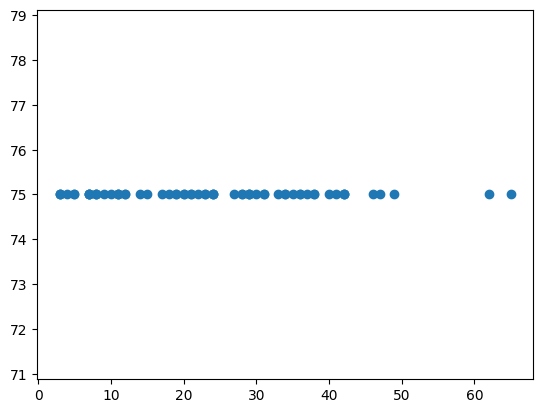

In [14]:
# gen_samps
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(nb_val, nb_gen)
